In [1]:
import numpy as np
import duckdb 
import logging 
import matplotlib.pyplot as plt

logging.basicConfig(
    level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s',
    filename='visualization.log'
)
logger = logging.getLogger(__name__)

In [2]:
### load duckdb table into pandas dfs 
con = None 
try: 
    # create and verify connection 
    con = duckdb.connect(database='project1.db', read_only=False) 
    logger.info("Connected to duckdb instance.") 

    # inserting tables 
    df = con.execute(f"""
        SELECT * FROM results_df;
    """).fetchdf()
    
    logger.info("results_df loaded into pandas dataframes")

except Exception as e:
    logger.error(f"An error occurred: {e}")

finally:
    if con:
        con.close()
        logger.info("Duckdb connection closed.")

The pandas.melt function is used here to transform the results dataframe into a more usable dataframe for making a bar chart, which is colored by model and separated by metric. 

In [3]:
df2 = df.melt(
    id_vars="Model",
    var_name="Metric",
    value_name="Value")

df2

,Model,Metric,Value
0,Linear_Regression,Overall_RMSE,890.8464
1,Random_Forest,Overall_RMSE,547.0304
2,Linear_Regression,Normal_RMSE,868.4940
3,Random_Forest,Normal_RMSE,524.8446
4,Linear_Regression,Extreme_RMSE,911.4645
5,Random_Forest,Extreme_RMSE,567.1979
6,Linear_Regression,Overall_MAE,699.2240
7,Random_Forest,Overall_MAE,395.3623
8,Linear_Regression,Normal_MAE,687.3566
9,Random_Forest,Normal_MAE,377.9069


The visualization was created with the goal of showing the difference in the models' performance in comparison to each other and to the three different scenarios. A bar chart was chosen because it allows for a clean visualization, while still showing all the necessary information and is easy to see the comparisons. There are two bar charts in the figure because of the difference in values between RMSE and MAE, and R^2. RMSE and MAE have similar value ranges that there is no issue plotting them on the same y-axis, however R^2 has a range of 0-1, which did not show well on the same plot as the other two metrics. They are shown in two separate graphs to increase readability and ensure that correct, and no misleading conclusions are drawn.

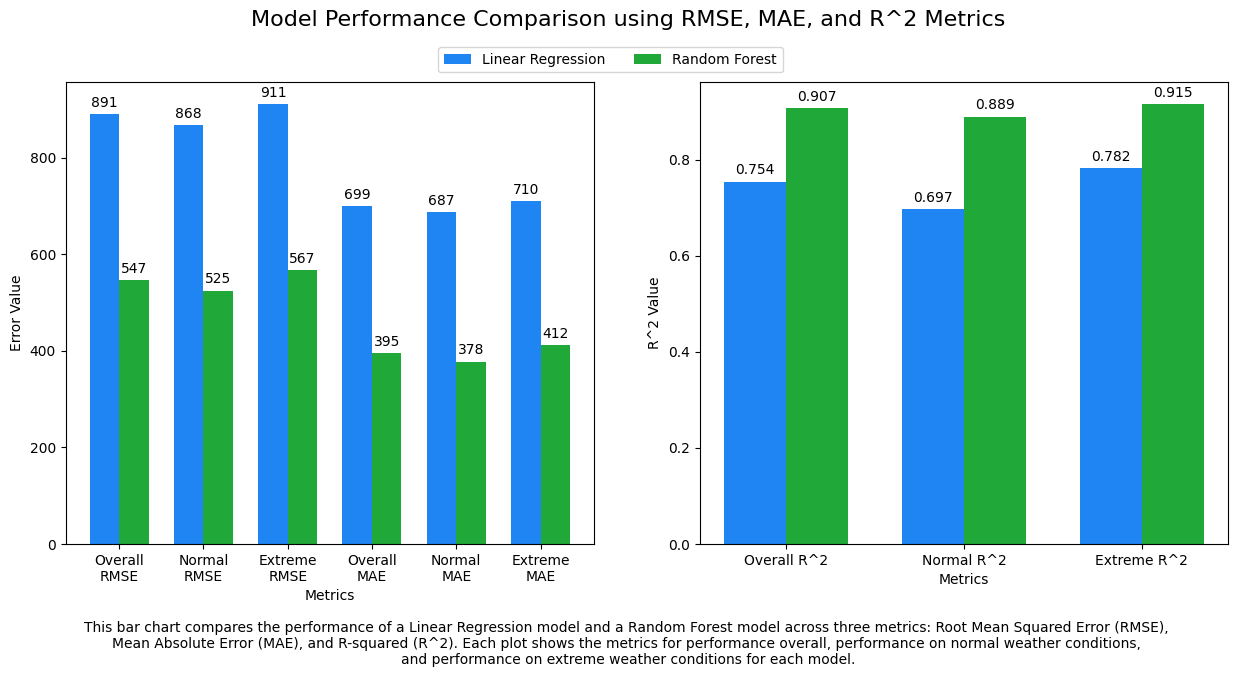

In [8]:
# create visualization 
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# split data into rmse+mae and r2
errordf = df2[df2['Metric'].str.contains('MAE|RMSE')]
r2df = df2[df2['Metric'].str.contains('R2')]

# get metrics 
e_metrics = errordf['Metric'].unique()
r2_metrics = r2df['Metric'].unique()

# split by model 
lr_error_values = [errordf[(errordf["Model"]=="Linear_Regression") & (errordf["Metric"]==m)]["Value"].values[0] for m in e_metrics]
rf_error_values = [errordf[(errordf["Model"]=="Random_Forest") & (errordf["Metric"]==m)]["Value"].values[0] for m in e_metrics]

lr_r2_values = [r2df[(r2df["Model"]=="Linear_Regression") & (r2df["Metric"]==m)]["Value"].values[0] for m in r2_metrics]
rf_r2_values = [r2df[(r2df["Model"]=="Random_Forest") & (r2df["Metric"]==m)]["Value"].values[0] for m in r2_metrics]

# x positions 
x1 = np.arange(len(e_metrics))
x2 = np.arange(len(r2_metrics))
width = 0.35 

# plot rmse and mae
bars11 = ax1.bar(x1 - width/2, lr_error_values, width, label="Linear Regression", color='#1f85f2')
bars12 = ax1.bar(x1 + width/2, rf_error_values, width, label="Random Forest", color='#20a839')
ax1.bar_label(bars11, fmt='%.0f', padding=3)
ax1.bar_label(bars12, fmt='%.0f', padding=3)

ax1.set_xticks(x1)
# making x labels more readable
e_metrics = ['Overall\nRMSE', 'Normal\nRMSE', 'Extreme\nRMSE', 'Overall\nMAE', 'Normal\nMAE', 'Extreme\nMAE']
ax1.set_xticklabels(e_metrics, ha="center")
ax1.set_ylabel("Error Value")
ax1.set_xlabel('Metrics')

# plot r2 
bars21 = ax2.bar(x2 - width/2, lr_r2_values, width, label="Linear Regression", color='#1f85f2')
bars22 = ax2.bar(x2 + width/2, rf_r2_values, width, label="Random Forest", color='#20a839')
ax2.bar_label(bars21, fmt='%.3f', padding=3)
ax2.bar_label(bars22, fmt='%.3f', padding=3)

ax2.set_xticks(x2)
# making x labels more readable 
r2_metrics = ['Overall R^2', 'Normal R^2', 'Extreme R^2']
ax2.set_xticklabels(r2_metrics, ha="center")
ax2.set_ylabel("R^2 Value")
ax2.set_xlabel('Metrics')

# title, legend, caption
fig.suptitle("Model Performance Comparison using RMSE, MAE, and R^2 Metrics", fontsize=16, x=0.5, y=1.0)
plt.legend(loc='best', bbox_to_anchor=(0.17, 1.09), ncols=2)
fig.text(0.5, -0.09, 
         "This bar chart compares the performance of a Linear Regression model and a Random Forest model across three metrics: Root Mean Squared Error (RMSE), \nMean Absolute Error (MAE), and R-squared (R^2). Each plot shows the metrics for performance overall, performance on normal weather conditions, \nand performance on extreme weather conditions for each model.", 
         ha='center')

# save as png 
plt.savefig('visualization.png', bbox_inches='tight')
logger.info("Visualization created and saved as visualization.png")

plt.show() 


Using this visualization, we can see that the Random Forest model performs much better than the Linear Regression model in all three scenarios, across all metrics even though the RMSE and MAE values are high for both models. In terms of the models' prediction accuracy for extreme weather events compared to normal or overall weather events, there is an slight increase in error for the extreme weather events. However, looking at the R^2 values, for both models the R^2 values for extreme weather events is higher than the other two scenarios, which means that there was less variation in the model for these scenarios. Even though these models contained some error, this information can be useful to electricity companies in the future in terms of working to forecast the effects of extreme weather events on their energy demand. 